# US Visa Prediction Project
**Life cycle of ML Project**

* Understanding the problem statement
* Data collection
* EDA (Exploratory data analysis)
* Data cleaning
* Data pre-processing
* Model training
* Choose best model

### About
The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

## 1) Problem statement
* OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications.
* As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:**
* This model is to check if Visa get approved or not based on the given dataset.
* This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.

## 2) Data collection
* The Dataset is part of Office of Foreign Labor Certification (OFLC)
* The data consists of 25480 Rows and 12 Columns

https://www.kaggle.com/datasets/moro23/easyvisa-dataset

### 2.1 Import data and require packaged

**Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings library**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # Used for interactive visualizations, especially for large datasets
import warnings # Used for non-fatal warnings, deprecated features (without stopping the program)

warnings.filterwarnings('ignore') # need to ignore warnings for better visualization of the data

%matplotlib inline

**Import the CSV data as Pandas DataFrame**

In [45]:
df = pd.read_csv("EasyVisa.csv")

**Show top 5 records**

In [46]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Shape of the Dataset**

In [47]:
df.shape

(25480, 12)

**Summary of the Dataset**

In [48]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


**Check datatypes in the dataset**

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


## 3) Exploring data

In [50]:
numeric_features = [feature for feature in df.columns if df[feature].dtypes != 'O'] # In numpy (nền tảng của Pandas) 'O' = object
categorical_features = [feature for feature in df.columns if df[feature].dtypes == 'O']

print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
We have 9 categorical features: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [51]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print("----------------------------")

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
----------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
----------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
----------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
----------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
----------------------------
region_of_employment
Northeast

**insight**
 - `case_id` have unique id for each column which can be dropped as it's no importance.
 - `continent` columns is highly bias towards asia. Hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important columns as most of them are yearly contracts.

## Univariate Analysis

* The term Univariate analysis refers to the analysis of one variable, prefix "Uni" means "one". The purpose of univariate analysis is to understand the distribution of values of a single variable

Other type of analysis are:

* **Bivariate Analysis**: The analysis of 2 variables
* **Multivariate Analysis**: The analysis of 2 or more variables 

### Numerical features

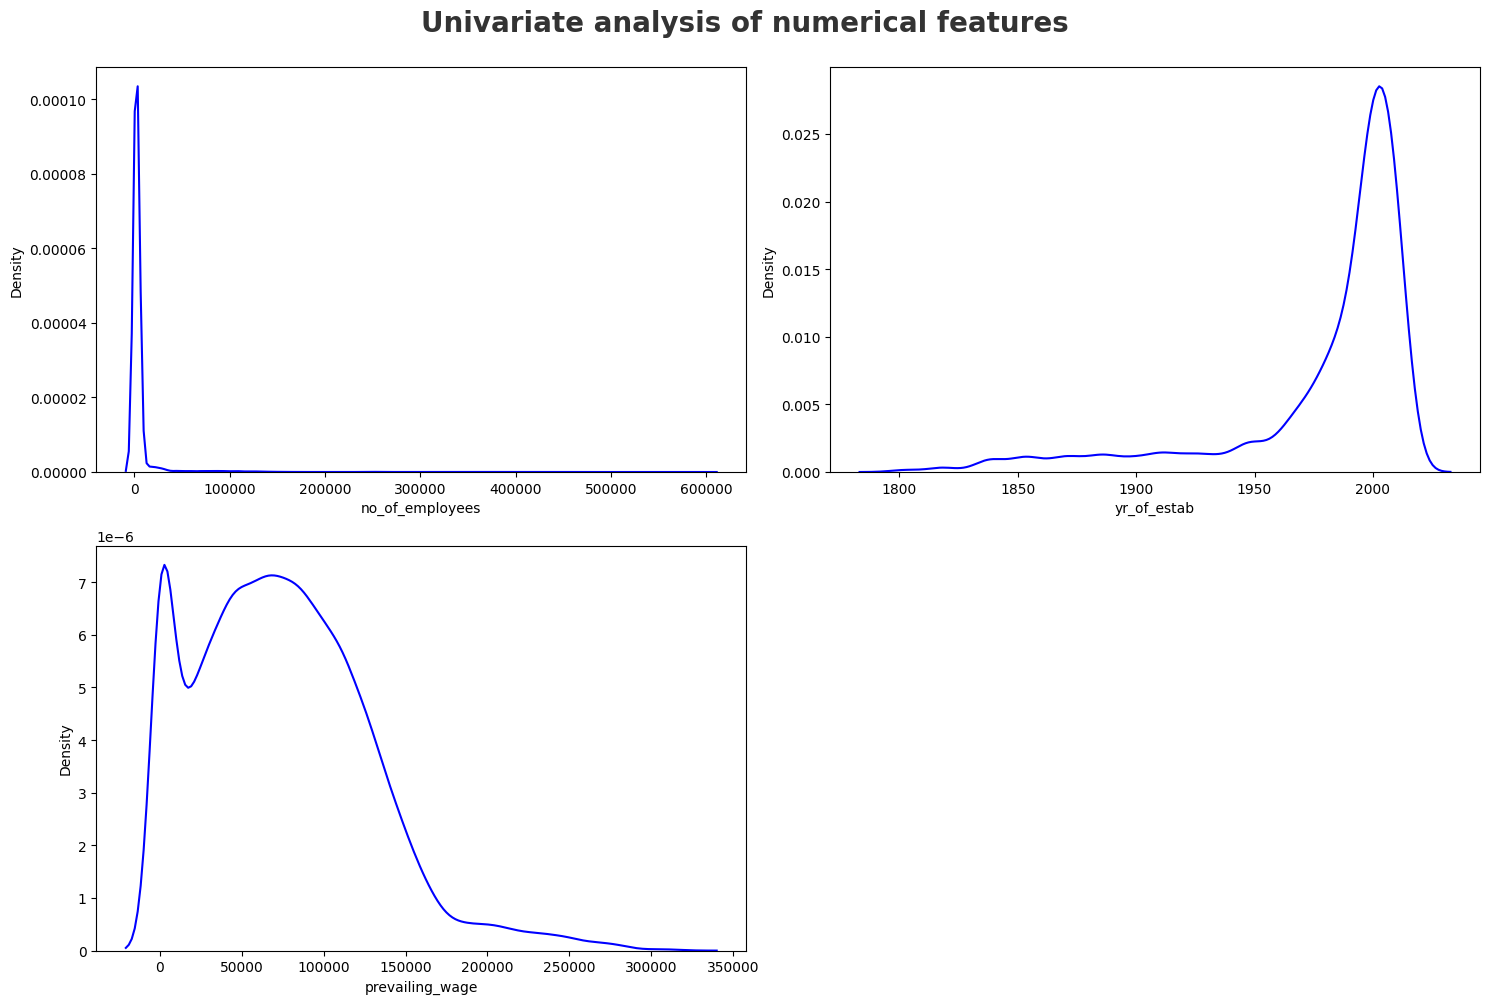

In [52]:
plt.figure(figsize=(15, 10)) # width = 15, height = 10
plt.suptitle('Univariate analysis of numerical features', fontsize=20, fontweight='bold', alpha=0.8, y=1.) # y=1.: Scale the the title with the vertical line

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1) # 2 rows, 2 columns, i+1: position of the plot
    sns.kdeplot(x=df[numeric_features[i]], color='blue') # x is the data, kde: kernel density (Biểu đồ phân phối mật độ)
    plt.xlabel(numeric_features[i]) # Give the x line the name of the feature
    plt.tight_layout() # Important: Automaticly scale plots

**Insights**

* `no_of_employees` columns look skewed but it may be because of the outlies
* `yr_of_estab` is discrete feature
* `prevailing_wage` is right-skewed distribution

Can use the `power transformation`, `log transformation` or `Z-score`

### Categorical features

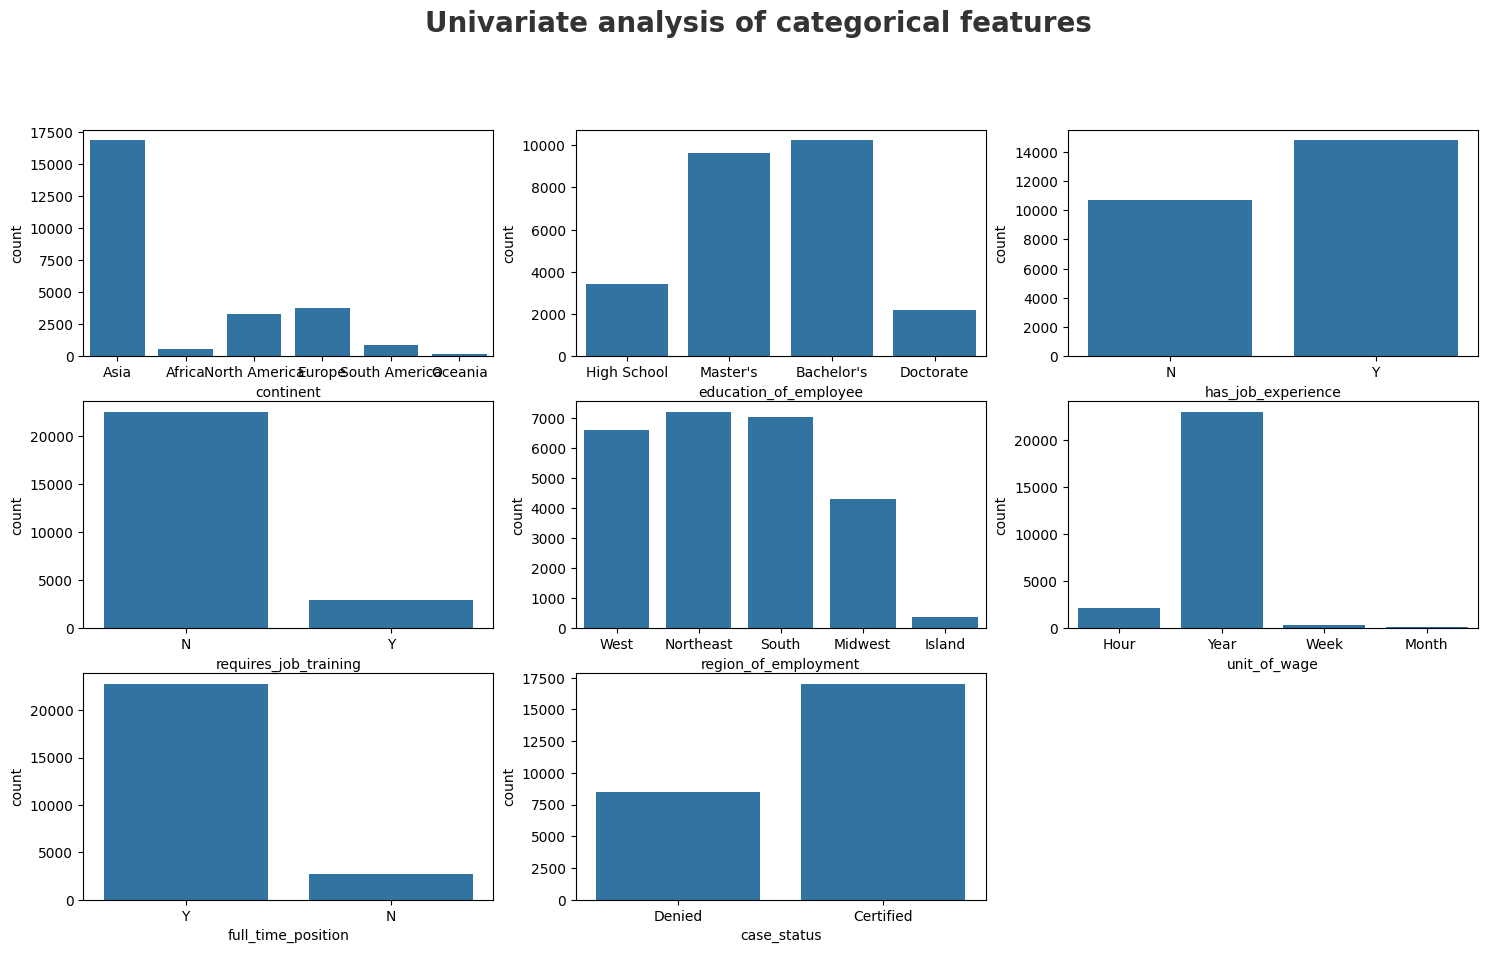

In [ ]:
categorical_features.remove('case_id')
plt.figure(figsize=(18, 10))
plt.suptitle('Univariate analysis of categorical features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout

**Insight**
* `continent`, `requires_job_training`, `unit_of_wage` and `full_time_position` columns have single category dominating
* And rest of the columns are balanced

### Multivariate analysis
* Multivariate analysis is the analysis of more than one variable.

In [56]:
discrete_features = [feature for feature in numeric_features if len(df[feature].unique()) <= 25]
continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))

We have 0 discrete features : []

We have 3 continuous_features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


### Check Multicollinearity in numerical features

In [59]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Insight**
* There is no multicollinearity between any variable

### Check Multicollinearity for Categorical features

* A chi-squared test (also chi-square or χ2 test) is a hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-square test

* A chi-square statistic is one way to show relationship between 2 categorical variable (**Right skewed distribution**)

* Here we test correlation of Categorical columns with Target column i.e case_status

Trong nhiều trường hợp dữ liệu categorical thường không tuân theo phân phối chuẩn. Phân phối Chi bình phương linh hoạt hơn, chỉ cần mẫu đủ lớn

Null Hypothesis ($H_0$): The feature is independent of target columns (No-Correlation)

Alternative Hypothesis ($H_1$): The Feature and Target column are not independent (Correalted)

In [ ]:
from scipy.stats import chi2_contingency
chi2_test=[]

